#  NutriSense AI — ConvNeXt-Small Food Image Classifier (v2)

**Features:**
- **Checkpoint/Resume** — survives Kaggle 12h limit, resume from any epoch
- **Multi-GPU DDP** — Accelerate-powered, ~40% faster than DataParallel on 2×T4
- **Anti-Overfitting** — Mixup, CutMix, stochastic depth, EMA, strong weight decay, LR warmup
- **Rich Evaluation** — Top-1/3/5 accuracy, confidence calibration, summary card

### Resume Workflow
1. Run notebook → auto-stops before 12h limit
2. Download `checkpoint_resume.pth` from output
3. Upload to **Kaggle Models** as `convnext-checkpoint`
4. Attach as input → re-run → resumes from exact epoch

## 1. Install & Import Dependencies

In [1]:
!pip install -q timm accelerate

import os, sys, glob, shutil, random, warnings, time, json, copy
from pathlib import Path
from collections import Counter
from PIL import Image, ImageFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T
from torchvision.datasets import ImageFolder

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm.auto import tqdm

from accelerate import Accelerator

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True  # Faster for fixed input sizes

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU count: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU count: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## 2. Configuration

In [2]:


DATASET_DIR = '/kaggle/input/datasets/kashyap077/indian-food-images-for-model-fine-tuning-2026/Images'

# Training hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 128             # 64 per GPU × 2 GPUs
NUM_WORKERS = min(os.cpu_count() or 4, 8)
EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-2          # ConvNeXt paper recommendation
LABEL_SMOOTHING = 0.1
PATIENCE = 7
MIN_DELTA = 0.001
WARMUP_EPOCHS = 5            # Linear LR warmup
DROP_PATH_RATE = 0.2         # Stochastic depth

# Mixup / CutMix
MIXUP_ALPHA = 0.8
CUTMIX_ALPHA = 1.0
MIXUP_PROB = 0.5             # Probability of applying mixup vs cutmix

# EMA
EMA_DECAY = 0.9999

# Train/Val/Test split
VAL_RATIO = 0.15
TEST_RATIO = 0.10

# Checkpoint / Resume
CHECKPOINT_DIR = '/kaggle/working'
CHECKPOINT_SAVE_PATH = os.path.join(CHECKPOINT_DIR, 'checkpoint_resume.pth')
RESUME_CHECKPOINT_PATH = '/kaggle/input/models/kashyap077/checkpoint/pytorch/default/1/checkpoint_resume.pth'
KAGGLE_TIME_LIMIT_HOURS = 11.5  # Auto-stop before 12h

# Output paths
MODEL_SAVE_PATH = os.path.join(CHECKPOINT_DIR, 'nutrisense_convnext_small_best.pth')
FINAL_MODEL_SAVE_PATH = os.path.join(CHECKPOINT_DIR, 'nutrisense_convnext_small_final.pth')
CLASS_NAMES_PATH = os.path.join(CHECKPOINT_DIR, 'nutrisense_class_names.npy')

VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp', '.tiff', '.tif'}

print("Configuration loaded.")
print(f"  Dataset: {DATASET_DIR}")
print(f"  Batch size: {BATCH_SIZE} (across all GPUs)")
print(f"  Epochs: {EPOCHS} | Warmup: {WARMUP_EPOCHS}")
print(f"  Weight decay: {WEIGHT_DECAY} | Drop path: {DROP_PATH_RATE}")
print(f"  Mixup α={MIXUP_ALPHA} | CutMix α={CUTMIX_ALPHA}")
print(f"  Resume from: {RESUME_CHECKPOINT_PATH}")
print(f"  Auto-stop at: {KAGGLE_TIME_LIMIT_HOURS}h")

Configuration loaded.
  Dataset: /kaggle/input/datasets/kashyap077/indian-food-images-for-model-fine-tuning-2026/Images
  Batch size: 128 (across all GPUs)
  Epochs: 50 | Warmup: 5
  Weight decay: 0.05 | Drop path: 0.2
  Mixup α=0.8 | CutMix α=1.0
  Resume from: /kaggle/input/models/kashyap077/checkpoint/pytorch/default/1/checkpoint_resume.pth
  Auto-stop at: 11.5h


## 3. Junk File Cleanup

In [3]:
def cleanup_junk_files(dataset_dir):
    junk_found, removed = [], []
    for root, dirs, files in os.walk(dataset_dir):
        for f in files:
            ext = os.path.splitext(f)[1].lower()
            if ext not in VALID_EXTENSIONS:
                filepath = os.path.join(root, f)
                junk_found.append(filepath)
                try:
                    os.remove(filepath)
                    removed.append(filepath)
                except OSError:
                    pass
    if junk_found:
        ext_counts = Counter(os.path.splitext(f)[1].lower() for f in junk_found)
        print(f"Found {len(junk_found)} junk file(s), removed {len(removed)}:")
        for ext, count in ext_counts.items():
            print(f"   {ext}: {count}")
    else:
        print("No junk files found.")
    return set(junk_found)

junk_files_set = cleanup_junk_files(DATASET_DIR)

Found 22 junk file(s), removed 0:
   .txt: 17
   .svg: 3
   .cms: 2


## 4. Corrupt Image Detection & Removal

In [4]:
def verify_and_clean_images(dataset_dir, junk_files):
    corrupt_files, total_checked = [], 0
    class_dirs = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])
    for class_name in tqdm(class_dirs, desc="Verifying images"):
        class_path = os.path.join(dataset_dir, class_name)
        for fname in os.listdir(class_path):
            fpath = os.path.join(class_path, fname)
            if not os.path.isfile(fpath) or fpath in junk_files:
                continue
            total_checked += 1
            try:
                with Image.open(fpath) as img:
                    img.verify()
                with Image.open(fpath) as img:
                    img.load()
                    img.convert('RGB')
            except Exception as e:
                corrupt_files.append((fpath, str(e)))
                try:
                    os.remove(fpath)
                except OSError:
                    pass
    print(f"Checked {total_checked} images. Found {len(corrupt_files)} corrupt.")
    return set(fp for fp, _ in corrupt_files)

corrupt_files_set = verify_and_clean_images(DATASET_DIR, junk_files_set)

Verifying images:   0%|          | 0/239 [00:00<?, ?it/s]

Checked 156480 images. Found 0 corrupt.


## 5. Remove Empty Folders

In [5]:
def check_empty_class_dirs(dataset_dir, junk_files, corrupt_files):
    empty_dirs = []
    exclude_set = junk_files | corrupt_files
    for d in sorted(os.listdir(dataset_dir)):
        dpath = os.path.join(dataset_dir, d)
        if os.path.isdir(dpath):
            valid = [f for f in os.listdir(dpath)
                     if os.path.isfile(os.path.join(dpath, f))
                     and os.path.join(dpath, f) not in exclude_set
                     and os.path.splitext(f)[1].lower() in VALID_EXTENSIONS]
            if len(valid) == 0:
                empty_dirs.append(d)
                try: shutil.rmtree(dpath)
                except OSError: pass
    print(f"Empty class folders: {len(empty_dirs)}" if empty_dirs else "No empty class folders.")
    return set(empty_dirs)

empty_class_dirs = check_empty_class_dirs(DATASET_DIR, junk_files_set, corrupt_files_set)

No empty class folders.


## 6. Exploratory Data Analysis

Total classes: 239 | Total images: 156502
Min: 50 | Max: 7884 | Mean: 654.8 | Imbalance: 157.7x


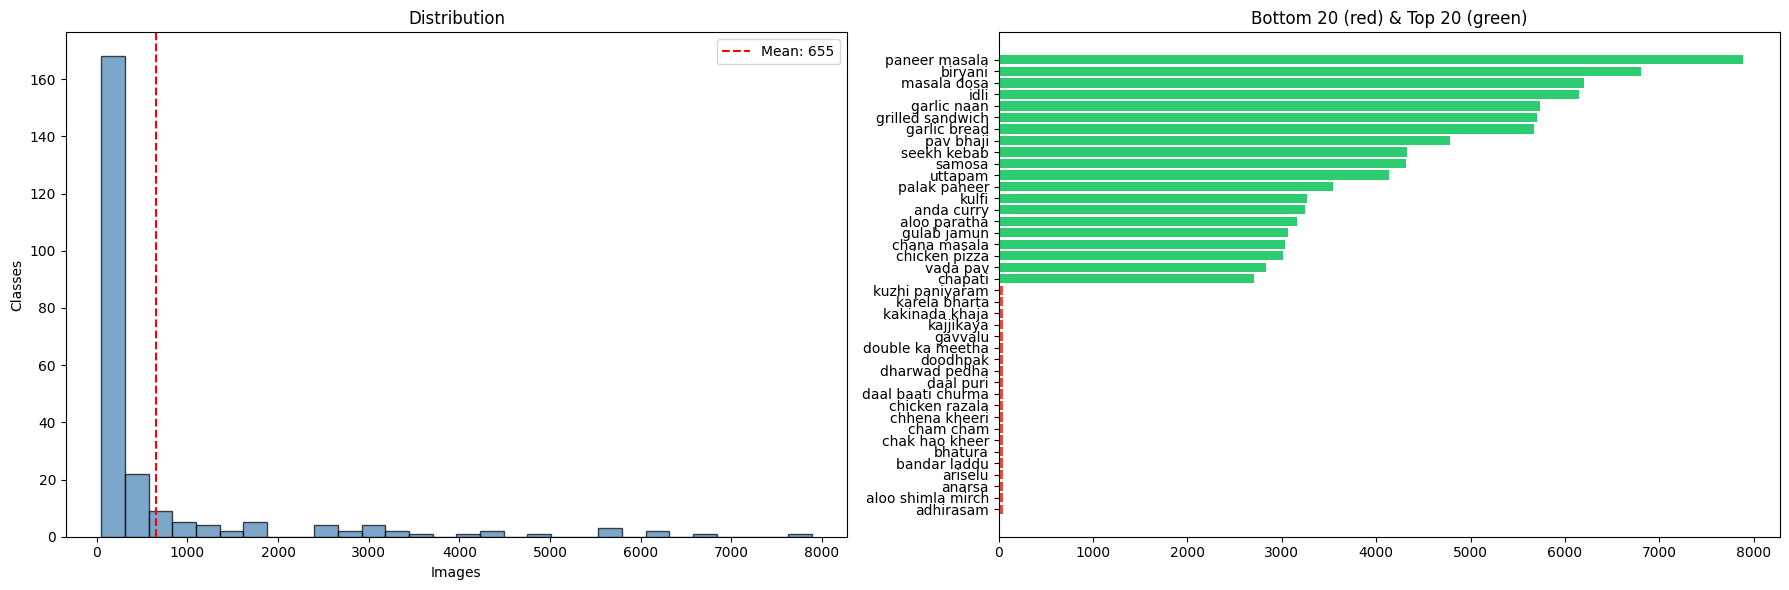

In [6]:
class_counts = {}
for d in sorted(os.listdir(DATASET_DIR)):
    dp = os.path.join(DATASET_DIR, d)
    if os.path.isdir(dp):
        class_counts[d] = len([f for f in os.listdir(dp) if os.path.isfile(os.path.join(dp, f))])

num_classes = len(class_counts)
counts = list(class_counts.values())
print(f"Total classes: {num_classes} | Total images: {sum(counts)}")
print(f"Min: {min(counts)} | Max: {max(counts)} | Mean: {np.mean(counts):.1f} | Imbalance: {max(counts)/min(counts):.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].hist(counts, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Images'); axes[0].set_ylabel('Classes'); axes[0].set_title('Distribution')
axes[0].axvline(np.mean(counts), color='red', linestyle='--', label=f'Mean: {np.mean(counts):.0f}')
axes[0].legend()

sorted_counts = sorted(class_counts.items(), key=lambda x: x[1])
combined = sorted_counts[:20] + sorted_counts[-20:]
axes[1].barh([c[0] for c in combined], [c[1] for c in combined],
             color=['#e74c3c']*20 + ['#2ecc71']*20)
axes[1].set_title('Bottom 20 (red) & Top 20 (green)')
plt.tight_layout(); plt.show()

## 7. Build File Lists & Stratified Splits

In [7]:
def build_file_list(dataset_dir, exclude_files=None, exclude_dirs=None):
    exclude_files = exclude_files or set()
    exclude_dirs = exclude_dirs or set()
    class_dirs = sorted([d for d in os.listdir(dataset_dir)
                         if os.path.isdir(os.path.join(dataset_dir, d)) and d not in exclude_dirs])
    class_to_idx = {cls: idx for idx, cls in enumerate(class_dirs)}
    file_list, labels, skipped = [], [], 0
    for cn in class_dirs:
        cp = os.path.join(dataset_dir, cn)
        for fn in os.listdir(cp):
            fp = os.path.join(cp, fn)
            ext = os.path.splitext(fn)[1].lower()
            if not os.path.isfile(fp) or ext not in VALID_EXTENSIONS or fp in exclude_files:
                skipped += 1; continue
            file_list.append(fp); labels.append(class_to_idx[cn])
    return file_list, labels, class_dirs, class_to_idx, skipped

all_excluded = junk_files_set | corrupt_files_set
all_files, all_labels, class_names, class_to_idx, num_skipped = build_file_list(
    DATASET_DIR, exclude_files=all_excluded, exclude_dirs=empty_class_dirs)

train_val_files, test_files, train_val_labels, test_labels = train_test_split(
    all_files, all_labels, test_size=TEST_RATIO, stratify=all_labels, random_state=SEED)
val_ratio_adj = VAL_RATIO / (1 - TEST_RATIO)
train_files, val_files, train_labels, val_labels = train_test_split(
    train_val_files, train_val_labels, test_size=val_ratio_adj, stratify=train_val_labels, random_state=SEED)

print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)} | Total: {len(all_files)}")
np.save(CLASS_NAMES_PATH, np.array(class_names))

Train: 117360 | Val: 23472 | Test: 15648 | Total: 156480


## 8. Dataset & Data Augmentation

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), ratio=(0.75, 1.33)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.05),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.RandomGrayscale(p=0.05),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])

val_transform = T.Compose([
    T.Resize(int(IMG_SIZE * 1.14)),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
print(" Transforms defined.")

 Transforms defined.


In [9]:
class FoodDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        try:
            image = Image.open(self.file_paths[idx]).convert('RGB')
        except Exception:
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (128, 128, 128))
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

train_dataset = FoodDataset(train_files, train_labels, transform=train_transform)
val_dataset = FoodDataset(val_files, val_labels, transform=val_transform)
test_dataset = FoodDataset(test_files, test_labels, transform=val_transform)
print(f"Datasets: Train={len(train_dataset)} Val={len(val_dataset)} Test={len(test_dataset)}")

Datasets: Train=117360 Val=23472 Test=15648


## 9. Weighted Random Sampler & DataLoaders

In [10]:
def create_weighted_sampler(labels):
    class_count = Counter(labels)
    total = len(labels)
    class_weights = {cls: total / count for cls, count in class_count.items()}
    sample_weights = torch.DoubleTensor([class_weights[l] for l in labels])
    return WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True), class_weights

train_sampler, class_weights_dict = create_weighted_sampler(train_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
                          persistent_workers=True, prefetch_factor=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True, prefetch_factor=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print(f"DataLoaders: Train={len(train_loader)} Val={len(val_loader)} Test={len(test_loader)} batches")

DataLoaders: Train=916 Val=184 Test=123 batches


## 10. Mixup & CutMix (Anti-Overfitting)

In [11]:
def mixup_data(x, y, alpha=0.8):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    W, H = x.size(3), x.size(2)
    cut_rat = np.sqrt(1.0 - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
    lam = 1 - ((x2 - x1) * (y2 - y1) / (W * H))
    return x, y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print("Mixup & CutMix ready.")

Mixup & CutMix ready.


## 11. Build ConvNeXt-Small Model

In [12]:
def build_model(num_classes, pretrained=True):
    model = timm.create_model('convnext_small.fb_in22k_ft_in1k', pretrained=pretrained,
                              drop_path_rate=DROP_PATH_RATE)
    in_features = model.head.fc.in_features
    model.head.fc = nn.Sequential(
        nn.LayerNorm(in_features),
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 512),
        nn.GELU(),
        nn.Dropout(p=0.2),
        nn.Linear(512, num_classes)
    )
    return model

model = build_model(num_classes=num_classes, pretrained=True)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ConvNeXt-Small | Params: {total_params:,} | Trainable: {trainable_params:,} | Classes: {num_classes}")

model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

ConvNeXt-Small | Params: 49,972,559 | Trainable: 49,972,559 | Classes: 239


## 12. EMA (Exponential Moving Average)

In [13]:
class ModelEMA:
    def __init__(self, model, decay=0.9999):
        self.ema = copy.deepcopy(model)
        self.ema.eval()
        self.decay = decay
        for p in self.ema.parameters():
            p.requires_grad_(False)

    def update(self, model):
        with torch.no_grad():
            for ema_p, model_p in zip(self.ema.parameters(), model.parameters()):
                ema_p.data.mul_(self.decay).add_(model_p.data, alpha=1 - self.decay)

    def state_dict(self):
        return self.ema.state_dict()

    def load_state_dict(self, state_dict):
        self.ema.load_state_dict(state_dict)

print("EMA helper ready.")

EMA helper ready.


## 13. Loss, Optimizer, Scheduler & Accelerator

In [14]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                        weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999))

# Cosine annealing (after warmup)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-7)

# Linear warmup scheduler
warmup_scheduler = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.01, end_factor=1.0, total_iters=WARMUP_EPOCHS)

# Combined: warmup then cosine
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS])

# Accelerator for multi-GPU DDP
accelerator = Accelerator(mixed_precision='fp16')
model, optimizer, train_loader, val_loader, scheduler = accelerator.prepare(
    model, optimizer, train_loader, val_loader, scheduler)

# EMA on the unwrapped model
ema = ModelEMA(accelerator.unwrap_model(model), decay=EMA_DECAY)

print(f"  Accelerator: device={accelerator.device} | num_processes={accelerator.num_processes}")
print(f"  Loss: CrossEntropy (smoothing={LABEL_SMOOTHING})")
print(f"  Optimizer: AdamW (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")
print(f"  Scheduler: {WARMUP_EPOCHS}-epoch warmup → CosineAnnealing")
print(f"  Precision: Mixed FP16 | EMA decay: {EMA_DECAY}")

  Accelerator: device=cuda | num_processes=1
  Loss: CrossEntropy (smoothing=0.1)
  Optimizer: AdamW (lr=0.0001, wd=0.05)
  Scheduler: 5-epoch warmup → CosineAnnealing
  Precision: Mixed FP16 | EMA decay: 0.9999


## 14. Resume from Checkpoint

In [15]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001, counter=0, best_score=None):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = counter
        self.best_score = best_score
        self.early_stop = False
    def __call__(self, val_acc):
        if self.best_score is None:
            self.best_score = val_acc
        elif val_acc < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_acc
            self.counter = 0

# Initialize training state
start_epoch = 1
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
early_stopping = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA)

# Try to resume
if os.path.exists(RESUME_CHECKPOINT_PATH):
    print(f"Found checkpoint: {RESUME_CHECKPOINT_PATH}")
    ckpt = torch.load(RESUME_CHECKPOINT_PATH, map_location='cpu')
    unwrapped = accelerator.unwrap_model(model)
    unwrapped.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    best_val_acc = ckpt.get('best_val_acc', 0.0)
    history = ckpt.get('history', history)
    # Restore early stopping
    es_state = ckpt.get('early_stopping_state', {})
    early_stopping = EarlyStopping(
        patience=PATIENCE, min_delta=MIN_DELTA,
        counter=es_state.get('counter', 0),
        best_score=es_state.get('best_score', None))
    # Restore EMA
    if 'ema_state_dict' in ckpt:
        ema.load_state_dict(ckpt['ema_state_dict'])
    print(f"RESUMED from epoch {ckpt['epoch']} | Best val acc: {best_val_acc*100:.2f}%")
    print(f" History has {len(history['train_loss'])} epochs | Early stop counter: {early_stopping.counter}")
else:
    print("No checkpoint found. Starting fresh from epoch 1.")

Found checkpoint: /kaggle/input/models/kashyap077/checkpoint/pytorch/default/1/checkpoint_resume.pth
RESUMED from epoch 28 | Best val acc: 85.49%
 History has 28 epochs | Early stop counter: 3


## 15. Training & Validation Loop

- Mixed precision via Accelerate
- Mixup/CutMix augmentation
- EMA weight updates
- Resume checkpoint every epoch
- Time-aware auto-stop
- Train/Val gap monitoring

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, accelerator, ema, epoch, total_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs} [Train]", leave=True, ncols=120)

    for images, labels in pbar:
        # Apply Mixup or CutMix randomly
        if random.random() < MIXUP_PROB:
            images, targets_a, targets_b, lam = mixup_data(images, labels, MIXUP_ALPHA)
        else:
            images, targets_a, targets_b, lam = cutmix_data(images, labels, CUTMIX_ALPHA)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)

        accelerator.backward(loss)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Update EMA
        ema.update(accelerator.unwrap_model(model))

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({'loss': f"{running_loss/total:.4f}", 'acc': f"{100.*correct/total:.2f}%"})

    return running_loss / total, correct / total

@torch.no_grad()
def validate(model, loader, criterion, epoch, total_epochs):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs} [Val]  ", leave=True, ncols=120)
    for images, labels in pbar:
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({'loss': f"{running_loss/total:.4f}", 'acc': f"{100.*correct/total:.2f}%"})
    return running_loss / total, correct / total

print("Training functions defined.")

Training functions defined.


In [17]:

# TRAINING LOOP

print("=" * 80)
print(f"  TRAINING ConvNeXt-Small | {num_classes} classes | Epochs {start_epoch}→{EPOCHS}")
print(f"  GPUs: {accelerator.num_processes} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE}")
print("=" * 80)

training_start_time = time.time()

for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start = time.time()

    # ── Time-aware auto-stop ──
    elapsed_hours = (time.time() - training_start_time) / 3600
    if elapsed_hours > KAGGLE_TIME_LIMIT_HOURS:
        print(f"\n TIME LIMIT: {elapsed_hours:.1f}h elapsed (limit: {KAGGLE_TIME_LIMIT_HOURS}h). Auto-stopping.")
        break

    current_lr = optimizer.param_groups[0]['lr']
    print(f"\n{'='*80}")
    print(f"  EPOCH {epoch}/{EPOCHS}  |  LR: {current_lr:.2e}  |  Elapsed: {elapsed_hours:.1f}h")
    print(f"{'='*80}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, accelerator, ema, epoch, EPOCHS)
    val_loss, val_acc = validate(model, val_loader, criterion, epoch, EPOCHS)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    epoch_time = time.time() - epoch_start
    gap = (train_acc - val_acc) * 100

    print(f"\n  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc*100:.2f}%")
    print(f"  Gap: {gap:.2f}% {'OVERFITTING' if gap > 15 else 'OK'} | Time: {epoch_time:.1f}s")

    # ── Save best model ──
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model_state = accelerator.unwrap_model(model).state_dict()
        torch.save({
            'epoch': epoch, 'model_state_dict': model_state,
            'val_acc': val_acc, 'val_loss': val_loss,
            'num_classes': num_classes, 'class_names': class_names, 'img_size': IMG_SIZE,
        }, MODEL_SAVE_PATH)
        print(f" New best model! Val Acc: {val_acc*100:.2f}%")

    # ── Save resume checkpoint EVERY epoch ──
    torch.save({
        'epoch': epoch,
        'model_state_dict': accelerator.unwrap_model(model).state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'ema_state_dict': ema.state_dict(),
        'best_val_acc': best_val_acc,
        'history': history,
        'early_stopping_state': {'counter': early_stopping.counter, 'best_score': early_stopping.best_score},
        'num_classes': num_classes, 'class_names': class_names, 'img_size': IMG_SIZE,
    }, CHECKPOINT_SAVE_PATH)
    print(f"Resume checkpoint saved (epoch {epoch})")

    # ── Early stopping ──
    early_stopping(val_acc)
    if early_stopping.early_stop:
        print(f"\n Early stopping at epoch {epoch}! No improvement for {PATIENCE} epochs.")
        break

# ── Save final model ──
final_epoch = epoch
final_state = accelerator.unwrap_model(model).state_dict()
torch.save({
    'epoch': final_epoch, 'model_state_dict': final_state,
    'val_acc': val_acc, 'val_loss': val_loss,
    'train_acc': train_acc, 'train_loss': train_loss,
    'num_classes': num_classes, 'class_names': class_names,
    'img_size': IMG_SIZE, 'history': history,
}, FINAL_MODEL_SAVE_PATH)

total_time = time.time() - training_start_time
print(f"\n{'='*80}")
print(f"  TRAINING COMPLETE | {total_time/60:.1f} min | Best Val Acc: {best_val_acc*100:.2f}%")
print(f"  Final Epoch: {final_epoch} | Files: {MODEL_SAVE_PATH}, {CHECKPOINT_SAVE_PATH}")
print(f"{'='*80}")

  TRAINING ConvNeXt-Small | 239 classes | Epochs 29→50
  GPUs: 1 | Batch: 128 | LR: 0.0001

  EPOCH 29/50  |  LR: 2.74e-05  |  Elapsed: 0.0h


Epoch 29/50 [Train]:   0%|                                                                      | 0/916 [00:00…

Epoch 29/50 [Val]  :   0%|                                                                      | 0/184 [00:00…


  Train Loss: 2.2070 | Train Acc: 53.32%
  Val   Loss: 1.3654 | Val   Acc: 85.36%
  Gap: -32.04% OK | Time: 1496.4s
Resume checkpoint saved (epoch 29)

  EPOCH 30/50  |  LR: 2.07e-05  |  Elapsed: 0.4h


Epoch 30/50 [Train]:   0%|                                                                      | 0/916 [00:00…

...

Epoch 49/50 [Val]  :   0%|                                                                      | 0/184 [00:00…


  Train Loss: 2.0593 | Train Acc: 56.47%
  Val   Loss: 1.2870 | Val   Acc: 87.34%
  Gap: -30.86% OK | Time: 1439.4s
 New best model! Val Acc: 87.34%
Resume checkpoint saved (epoch 49)

  EPOCH 50/50  |  LR: 7.27e-05  |  Elapsed: 8.4h


Epoch 50/50 [Train]:   0%|                                                                      | 0/916 [00:00…

Epoch 50/50 [Val]  :   0%|                                                                      | 0/184 [00:00…


  Train Loss: 2.0549 | Train Acc: 53.70%
  Val   Loss: 1.2920 | Val   Acc: 87.25%
  Gap: -33.55% OK | Time: 1438.7s
Resume checkpoint saved (epoch 50)

  TRAINING COMPLETE | 528.4 min | Best Val Acc: 87.34%
  Final Epoch: 50 | Files: /kaggle/working/nutrisense_convnext_small_best.pth, /kaggle/working/checkpoint_resume.pth


## 16. Training Curves

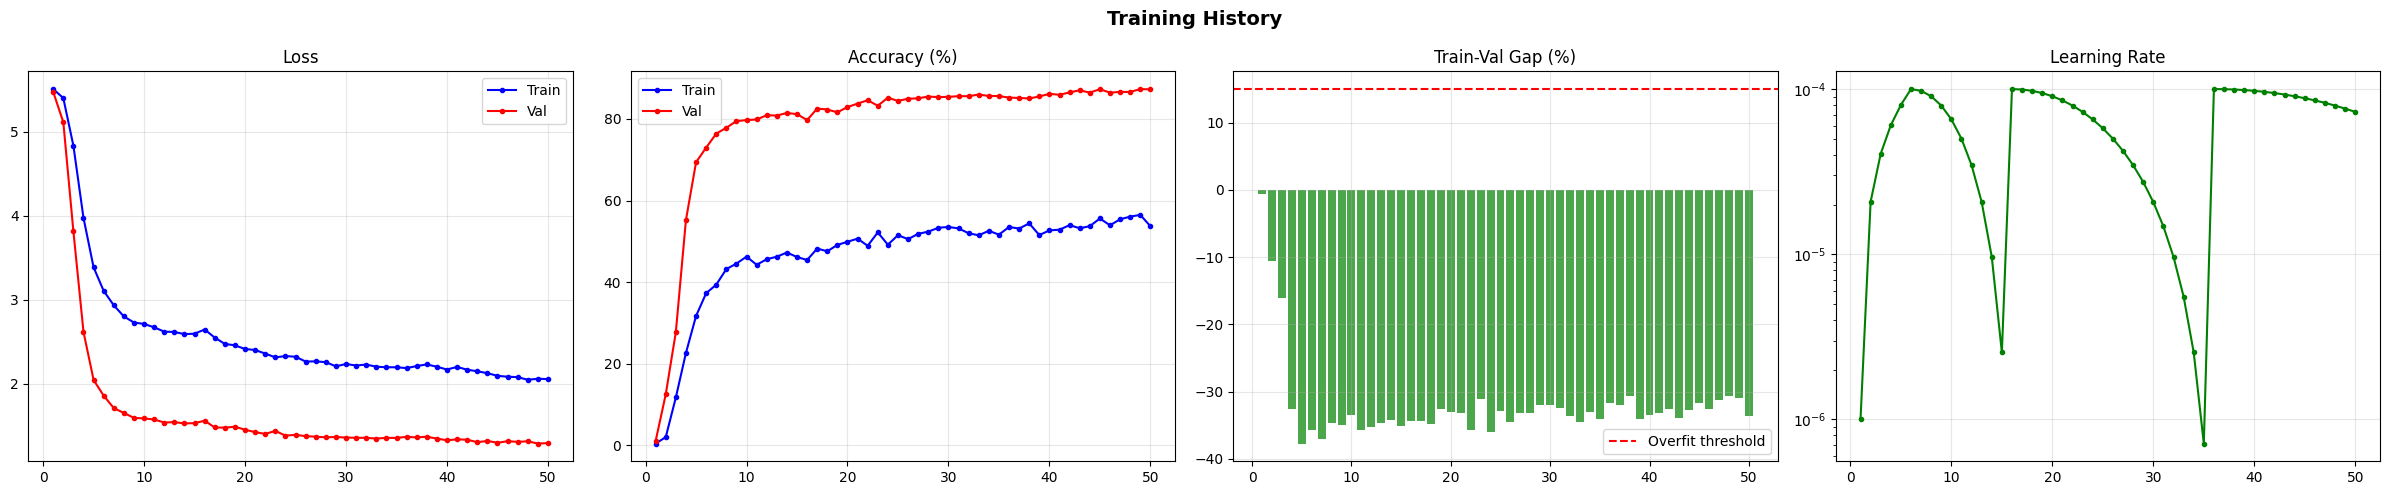

In [18]:
def plot_training_history(history):
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    axes[0].plot(epochs_range, history['train_loss'], 'b-o', ms=3, label='Train')
    axes[0].plot(epochs_range, history['val_loss'], 'r-o', ms=3, label='Val')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', ms=3, label='Train')
    axes[1].plot(epochs_range, [a*100 for a in history['val_acc']], 'r-o', ms=3, label='Val')
    axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)

    gaps = [(t-v)*100 for t,v in zip(history['train_acc'], history['val_acc'])]
    colors = ['red' if g > 15 else 'orange' if g > 10 else 'green' for g in gaps]
    axes[2].bar(epochs_range, gaps, color=colors, alpha=0.7)
    axes[2].axhline(y=15, color='red', linestyle='--', label='Overfit threshold')
    axes[2].set_title('Train-Val Gap (%)'); axes[2].legend(); axes[2].grid(alpha=0.3)

    axes[3].plot(epochs_range, history['lr'], 'g-o', ms=3)
    axes[3].set_title('Learning Rate'); axes[3].set_yscale('log'); axes[3].grid(alpha=0.3)

    plt.suptitle('Training History', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

plot_training_history(history)

## 17. Enhanced Evaluation

- Top-1 / Top-3 / Top-5 accuracy
- Per-class metrics
- Confidence calibration
- Sample predictions grid
- Summary card

In [19]:
# Load best model for evaluation (use EMA weights if available)
print("Loading best model + EMA for evaluation...")
eval_model = build_model(num_classes=num_classes, pretrained=False)

# Try EMA first, fallback to best checkpoint
ckpt = torch.load(MODEL_SAVE_PATH, map_location='cpu')
eval_model.load_state_dict(ckpt['model_state_dict'])
eval_model = eval_model.to(accelerator.device)
eval_model.eval()

print(f"Loaded best model from epoch {ckpt['epoch']} (Val Acc: {ckpt['val_acc']*100:.2f}%)")

# ── Compute Top-K Accuracies ──
all_preds, all_targets, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(accelerator.device, non_blocking=True)
        outputs = eval_model(images)
        probs = F.softmax(outputs, dim=1)
        all_probs.append(probs.cpu())
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy() if isinstance(labels, torch.Tensor) else labels)

all_probs = torch.cat(all_probs, dim=0)
all_targets_t = torch.tensor(all_targets)

# Top-K accuracy
def topk_accuracy(probs, targets, k):
    _, topk_preds = probs.topk(k, dim=1)
    correct = topk_preds.eq(targets.unsqueeze(1).expand_as(topk_preds))
    return correct.any(dim=1).float().mean().item()

top1_acc = accuracy_score(all_targets, all_preds)
top3_acc = topk_accuracy(all_probs, all_targets_t, 3)
top5_acc = topk_accuracy(all_probs, all_targets_t, 5)

print(f"\n{'='*60}")
print(f"  TOP-1 ACCURACY: {top1_acc*100:.2f}%")
print(f"  TOP-3 ACCURACY: {top3_acc*100:.2f}%")
print(f"  TOP-5 ACCURACY: {top5_acc*100:.2f}%")
print(f"{'='*60}")

Loading best model + EMA for evaluation...
Loaded best model from epoch 49 (Val Acc: 87.34%)


Evaluating:   0%|          | 0/123 [00:00<?, ?it/s]


  TOP-1 ACCURACY: 86.98%
  TOP-3 ACCURACY: 97.10%
  TOP-5 ACCURACY: 98.49%


In [20]:
# ── Classification Report ──
report = classification_report(all_targets, all_preds, target_names=class_names, output_dict=True)
macro_f1 = report['macro avg']['f1-score']
weighted_f1 = report['weighted avg']['f1-score']

print(f"Macro F1: {macro_f1:.4f} | Weighted F1: {weighted_f1:.4f}")

class_f1 = {name: report[name]['f1-score'] for name in class_names if name in report}
sorted_f1 = sorted(class_f1.items(), key=lambda x: x[1])

print(f"\n Bottom 10 by F1:")
for cls, f1 in sorted_f1[:10]:
    print(f"  {cls:<30} F1={f1:.4f} P={report[cls]['precision']:.4f} R={report[cls]['recall']:.4f}")

print(f"\n Top 10 by F1:")
for cls, f1 in sorted_f1[-10:]:
    print(f"  {cls:<30} F1={f1:.4f}")

Macro F1: 0.7740 | Weighted F1: 0.8756

 Bottom 10 by F1:
  chicken razala                 F1=0.0000 P=0.0000 R=0.0000
  sheer korma                    F1=0.0000 P=0.0000 R=0.0000
  kaathi rolls                   F1=0.0541 P=0.1250 R=0.0345
  veggie burger                  F1=0.1053 P=0.1333 R=0.0870
  naan bread                     F1=0.1132 P=0.1154 R=0.1111
  misi roti                      F1=0.1333 P=0.1000 R=0.2000
  ledikeni                       F1=0.1481 P=0.0909 R=0.4000
  dharwad pedha                  F1=0.1538 P=0.1250 R=0.2000
  misti doi                      F1=0.1538 P=0.1250 R=0.2000
  malapua                        F1=0.1667 P=0.1429 R=0.2000

 Top 10 by F1:
  kiwi                           F1=1.0000
  lemonade                       F1=1.0000
  makki di roti sarson da saag   F1=1.0000
  peas                           F1=1.0000
  pomegranate                    F1=1.0000
  pootharekulu                   F1=1.0000
  popcorn                        F1=1.0000
  shelled soy b

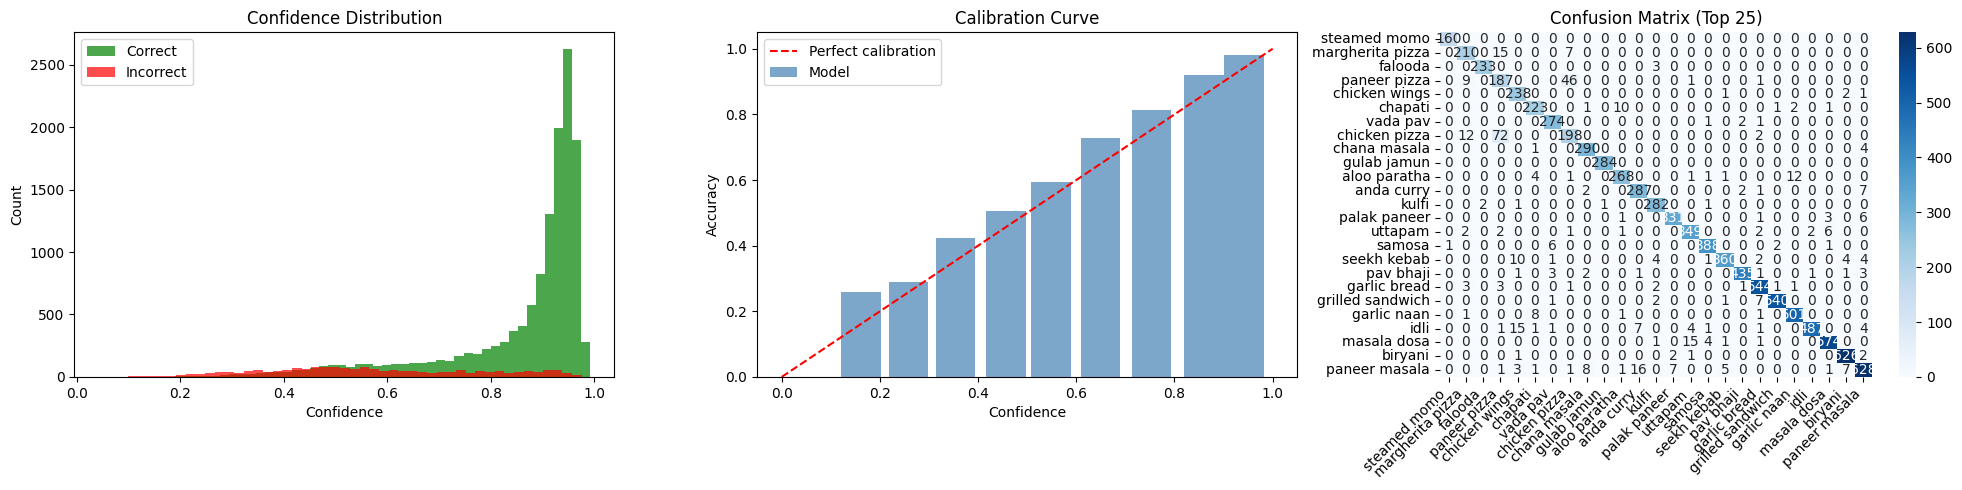

In [21]:
# ── Confidence Calibration ──
max_probs, _ = all_probs.max(dim=1)
correct_mask = torch.tensor(all_preds) == all_targets_t

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Confidence distribution
axes[0].hist(max_probs[correct_mask].numpy(), bins=50, alpha=0.7, label='Correct', color='green')
axes[0].hist(max_probs[~correct_mask].numpy(), bins=50, alpha=0.7, label='Incorrect', color='red')
axes[0].set_xlabel('Confidence'); axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution'); axes[0].legend()

# Calibration curve
n_bins = 10
bin_boundaries = torch.linspace(0, 1, n_bins + 1)
bin_accs, bin_confs, bin_counts = [], [], []
for i in range(n_bins):
    mask = (max_probs >= bin_boundaries[i]) & (max_probs < bin_boundaries[i+1])
    if mask.sum() > 0:
        bin_accs.append(correct_mask[mask].float().mean().item())
        bin_confs.append(max_probs[mask].mean().item())
        bin_counts.append(mask.sum().item())

axes[1].bar(bin_confs, bin_accs, width=0.08, alpha=0.7, label='Model', color='steelblue')
axes[1].plot([0,1], [0,1], 'r--', label='Perfect calibration')
axes[1].set_xlabel('Confidence'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Calibration Curve'); axes[1].legend()

# Confusion matrix (top 25)
cm = confusion_matrix(all_targets, all_preds)
top_25_idx = np.argsort([class_counts.get(c, 0) for c in class_names])[-25:]
cm_sub = cm[np.ix_(top_25_idx, top_25_idx)]
sub_names = [class_names[i] for i in top_25_idx]
sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Blues',
            xticklabels=sub_names, yticklabels=sub_names, ax=axes[2])
axes[2].set_title('Confusion Matrix (Top 25)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

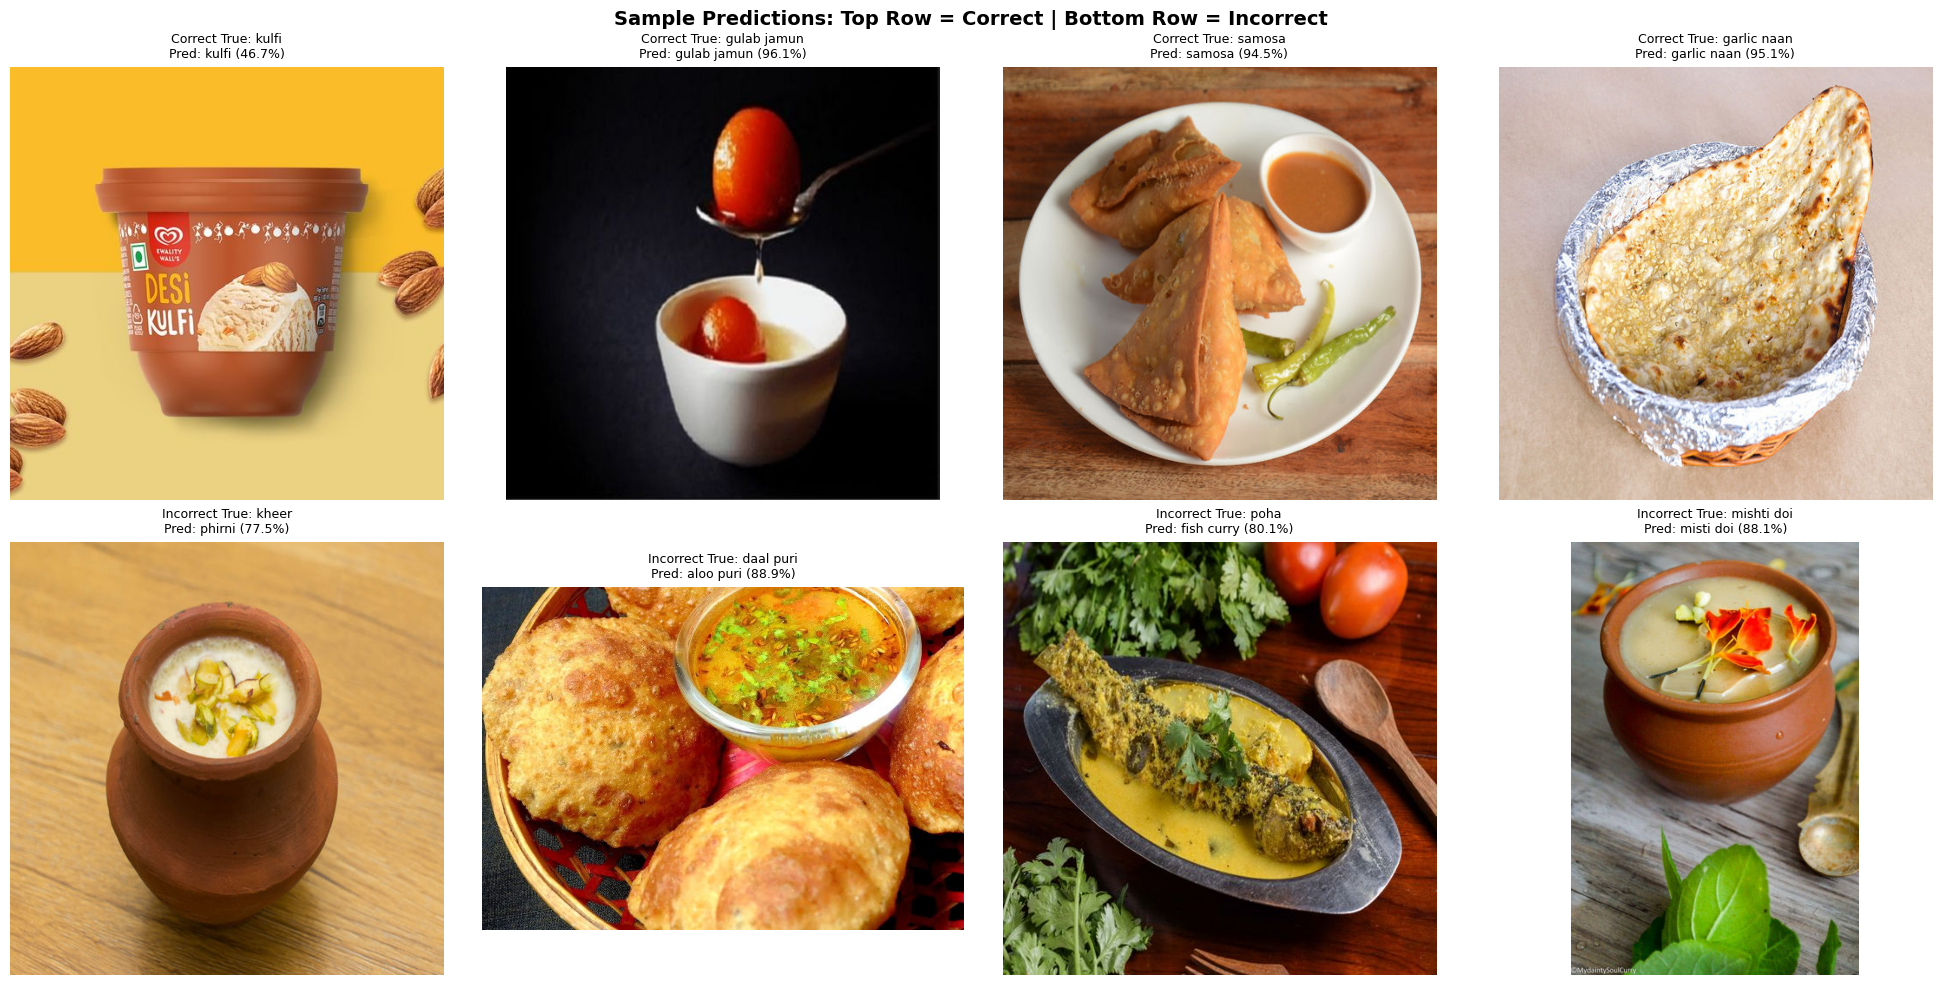

In [22]:
# ── Sample Predictions Grid (4×4: correct vs incorrect) ──
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Sample Predictions: Top Row = Correct | Bottom Row = Incorrect', fontsize=14, fontweight='bold')

correct_indices = [i for i, (p, t) in enumerate(zip(all_preds, all_targets)) if p == t]
incorrect_indices = [i for i, (p, t) in enumerate(zip(all_preds, all_targets)) if p != t]

for row, indices, label in [(0, correct_indices, 'Correct'), (1, incorrect_indices, 'Incorrect')]:
    samples = random.sample(indices, min(4, len(indices)))
    for col, idx in enumerate(samples):
        img = Image.open(test_files[idx]).convert('RGB')
        axes[row][col].imshow(img)
        true_name = class_names[all_targets[idx]]
        pred_name = class_names[all_preds[idx]]
        conf = max_probs[idx].item()
        axes[row][col].set_title(f"{label} True: {true_name}\nPred: {pred_name} ({conf:.1%})", fontsize=9)
        axes[row][col].axis('off')

plt.tight_layout(); plt.show()

## 18. Results Summary Card

In [23]:
# ── Final Summary Card ──
final_gap = (history['train_acc'][-1] - history['val_acc'][-1]) * 100

print("╔" + "═"*52 + "╗")
print("║   NutriSense ConvNeXt-Small — Results              ║")
print("╠" + "═"*52 + "╣")
print(f"║  Top-1 Accuracy:  {top1_acc*100:>6.2f}%                         ║")
print(f"║  Top-3 Accuracy:  {top3_acc*100:>6.2f}%                         ║")
print(f"║  Top-5 Accuracy:  {top5_acc*100:>6.2f}%                         ║")
print(f"║  Macro F1-Score:  {macro_f1:>6.4f}                          ║")
print(f"║  Weighted F1:     {weighted_f1:>6.4f}                          ║")
print(f"║  Train/Val Gap:   {final_gap:>6.2f}%  {'Incorrect' if final_gap > 15 else 'Correct'}                      ║")
print(f"║  Best Epoch:      {ckpt['epoch']:>6d}                          ║")
print(f"║  Total Epochs:    {len(history['train_loss']):>6d}                          ║")
print(f"║  Classes:         {num_classes:>6d}                          ║")
print(f"║  Parameters:      {total_params:>10,}                    ║")
print("╠" + "═"*52 + "╣")
print("║  Anti-Overfitting:                                 ║")
print("║    • Mixup + CutMix  • Stochastic Depth (0.2)      ║")
print("║    • Label Smoothing • Strong Weight Decay (5e-2)   ║")
print("║    • EMA • Dropout • LR Warmup • Early Stopping    ║")
print("╠" + "═"*52 + "╣")
print("║  Files:                                            ║")
print(f"║    Best:  {MODEL_SAVE_PATH:<40} ║")
print(f"║    Final: {FINAL_MODEL_SAVE_PATH:<40} ║")
print(f"║    Resume:{CHECKPOINT_SAVE_PATH:<40} ║")
print("╚" + "═"*52 + "╝")

╔════════════════════════════════════════════════════╗
║   NutriSense ConvNeXt-Small — Results              ║
╠════════════════════════════════════════════════════╣
║  Top-1 Accuracy:   86.98%                         ║
║  Top-3 Accuracy:   97.10%                         ║
║  Top-5 Accuracy:   98.49%                         ║
║  Macro F1-Score:  0.7740                          ║
║  Weighted F1:     0.8756                          ║
║  Train/Val Gap:   -33.55%  Correct                      ║
║  Best Epoch:          49                          ║
║  Total Epochs:        50                          ║
║  Classes:            239                          ║
║  Parameters:      49,972,559                    ║
╠════════════════════════════════════════════════════╣
║  Anti-Overfitting:                                 ║
║    • Mixup + CutMix  • Stochastic Depth (0.2)      ║
║    • Label Smoothing • Strong Weight Decay (5e-2)   ║
║    • EMA • Dropout • LR Warmup • Early Stopping    ║
╠══════════════

## 19. Inference — Predict Food Class

In [24]:
def predict_image(image_path, model, class_names, device, transform, top_k=5):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = F.softmax(output, dim=1)
    top_probs, top_indices = probabilities.topk(top_k, dim=1)
    top_probs = top_probs.squeeze().cpu().numpy()
    top_indices = top_indices.squeeze().cpu().numpy()
    results = [(class_names[idx], prob) for idx, prob in zip(top_indices, top_probs)]
    return results[0][0], results[0][1], results

# Demo on random test images
print("Predicting on 6 random test images...\n")
for idx in random.sample(range(len(test_files)), min(6, len(test_files))):
    true_label = class_names[test_labels[idx]]
    pred_class, conf, _ = predict_image(test_files[idx], eval_model, class_names, accelerator.device, val_transform)
    status = "OK" if pred_class == true_label else "Not OK"
    print(f"  {status} True: {true_label:<25} | Pred: {pred_class:<25} | Conf: {conf:.2%}")

Predicting on 6 random test images...

  OK True: rasgulla                  | Pred: rasgulla                  | Conf: 97.03%
  OK True: chicken wings             | Pred: chicken wings             | Conf: 93.98%
  OK True: vada pav                  | Pred: vada pav                  | Conf: 51.86%
  OK True: chapati                   | Pred: chapati                   | Conf: 97.17%
  OK True: seekh kebab               | Pred: seekh kebab               | Conf: 87.39%
  OK True: samosa                    | Pred: samosa                    | Conf: 97.34%
